# TRAS - Self Quenching


### Mounting the google drive

In [ ]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [ ]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [ ]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
#pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Self_Quenching_17Feb2026' #Sara's directory
pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026' #Fin's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['2026-02-10 12-14-03 TA BZ03.csv', '2026-02-10 12-05-10 TA BZ04.csv', 'NEW 2026-02-10 16-14-02 TA BZ02.csv', '2026-02-10 12-14-03 TA BZ03_Bootstrap_Distribution.png', '2026-02-10 12-14-03 TA BZ03_signal_vs_time.png', '2026-02-10 12-05-10 TA BZ04_Bootstrap_Distribution.png', '2026-02-10 12-05-10 TA BZ04_signal_vs_time.png', 'NEW 2026-02-10 16-14-02 TA BZ02_Bootstrap_Distribution.png', 'NEW 2026-02-10 16-14-02 TA BZ02_signal_vs_time.png', '2026-02-17 12-00-30 TA BZ08 THIRD .csv', '2026-02-17 12-00-30 TA BZ08 THIRD _Bootstrap_Distribution.png', '2026-02-17 12-00-30 TA BZ08 THIRD _signal_vs_time.png', '2026-02-17 12-19-17 TA BZ06 NEW.csv', '2026-02-17 12-19-17 TA BZ06 NEW_Bootstrap_Distribution.png', '2026-02-17 12-19-17 TA BZ06 NEW_signal_vs_time.png', '2026-02-17 12-46-19 TA BZ01 THIRD .csv', '2026-02-17 12-46-19 TA BZ01 THIRD _Bootstrap_Distribution.png', '2026-02-17 12-46-19 TA BZ01 THIRD _signal_vs_time.png', 'SelfQuenching_SternVolmer.png', '2026-02-17 12-46-19 TA BZ01 THIRD _full_a

## Loading and cleaning data
This step removes the negative bits before the exponential decay.

In [ ]:
csv_title = '2026-02-17 12-46-19 TA BZ01 THIRD .csv' #Modify this
clean_title = csv_title.replace(".csv", "")

df = pd.read_csv(
    os.path.join(pathTRAS, csv_title),
    sep=";",
    header=None,
    names=["time", "signal"]
)

df.head()

df = df.iloc[1:].reset_index(drop=True)
df = df.astype(float)

# index of maximum signal
idx_peak = df["signal"].idxmax()
df = df.loc[idx_peak:].reset_index(drop=True)


time = df["time"].to_numpy()
signal = df["signal"].to_numpy()

## Fitting an exponential

In [ ]:
# Exponential fit
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# Data - signal against time
x = time
y = signal

# Initial guesses based on max and min of dataset and bounds
A_init = y.max() - y.min()
tau_init = (x.max() - x.min()) / 5
C_init = y.min()
p0 = [A_init, tau_init, C_init] # Combined parameter for the 3 values
bounds = ([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf])

# Fit the exponential curve on the dataset and obtain error from covariance matrix
popt, pcov = curve_fit(exp_decay, x, y, p0=p0, bounds=bounds)
A, tau, C = popt
param_error = np.sqrt(np.diag(pcov))
A_error, tau_error, C_error = param_error

# Residuals
y_fit_data = exp_decay(x, *popt)
residuals = y - y_fit_data

# Bootstrapping
n_boot = 25000
tau_boot = []

for _ in range(n_boot):
    # Resample residuals with replacement
    resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)

    # Generate bootstrap dataset
    y_boot = y_fit_data + resampled_residuals

    try:
        # Refit
        popt_boot, _ = curve_fit(exp_decay, x, y_boot, p0=popt, bounds=bounds)
        tau_boot.append(popt_boot[1])
    except RuntimeError:
        # Skip failed fits
        continue

tau_boot = np.array(tau_boot)

# --- Bootstrap statistics ---
tau_std = np.std(tau_boot)
ci_low, ci_high = np.percentile(tau_boot, [2.5, 97.5])

print(f"Best-fit tau = {tau:.3f} ns")
print(f"Bootstrap standard error = {tau_std:.3f} ns")
print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}] ns")


Best-fit tau = 889.567 ns
Bootstrap standard error = 2.842 ns
95% CI = [884.107, 895.113] ns


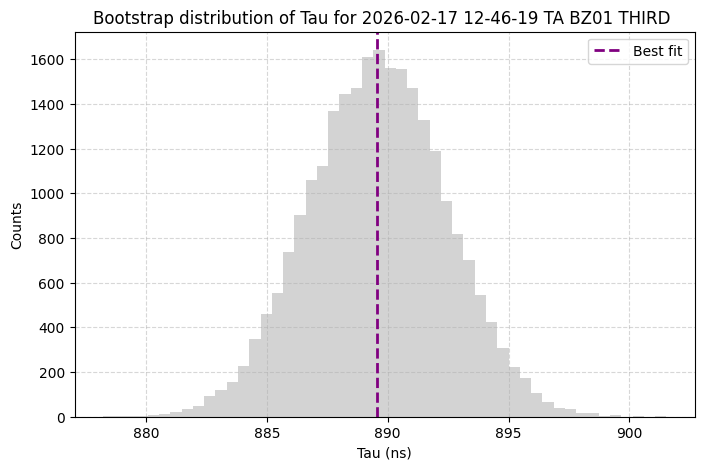

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    tau_boot,
    bins=50,
    facecolor='#D3D3D3',     # inside of bars
    #edgecolor='white',   # purple outline
    linewidth=1.5,         # thickness of the outline
    alpha=1.0              # fully opaque inside (white)
)

# Add vertical line for best-fit tau
plt.axvline(tau, color='purple', linestyle='--', linewidth=2, label='Best fit')

plt.xlabel("Tau (ns)")
plt.ylabel("Counts")
plt.title(f"Bootstrap distribution of Tau for {clean_title}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# plt.savefig(
#     f"/content/drive/MyDrive/Colab Notebooks/TRAS/Self_Quenching_17Feb2026/{clean_title}_Bootstrap_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()


In [ ]:
print(A, tau, C)

12.3066415339028 889.5671440607437 0.004958925785762619



=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 889.56714
Tau bootstrap SE (ns): 2.84172
Tau 95% CI low (ns): 884.10738
Tau 95% CI high (ns): 895.11323


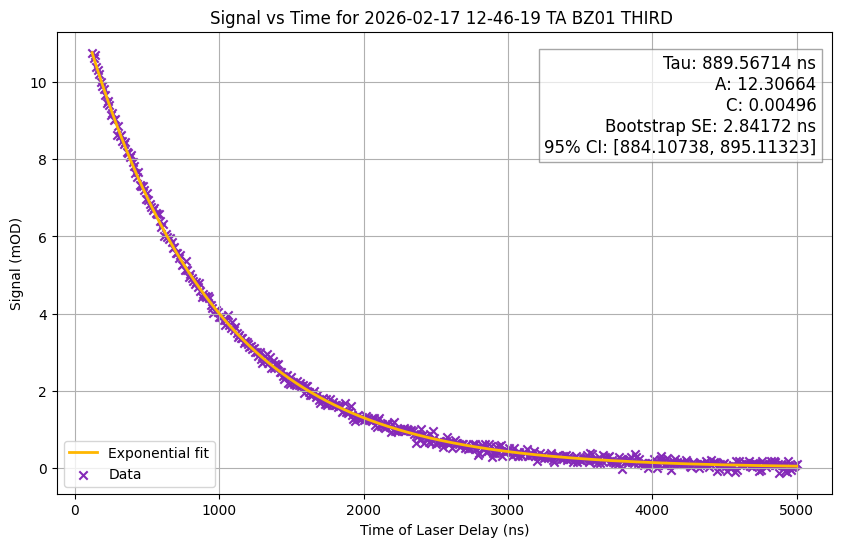

In [ ]:
# --- Create fine x-axis for smooth fitted curve ---
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = exp_decay(x_fit, *popt)

plt.figure(figsize=(10, 6))

# Plot the exponential fit
plt.plot(x_fit, y_fit, color='#FFB700', linewidth=2, label='Exponential fit')

# Plot the data points
plt.scatter(x, y, marker='x', color='#852AB8', label='Data')

# Title and labels
plt.title(f'Signal vs Time for {clean_title}')
plt.xlabel('Time of Laser Delay (ns)')
plt.ylabel('Signal (mOD)')

# Add best-fit parameters as text
plt.text(
    0.98, 0.95,
    f'Tau: {tau:.5f} ns\nA: {A:.5f}\nC: {C:.5f}\nBootstrap SE: {tau_std:.5f} ns\n95% CI: [{ci_low:.5f}, {ci_high:.5f}]',
    transform=plt.gca().transAxes,  # axes coordinates
    ha='right',
    va='top',
    fontsize=12,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.legend()
plt.grid(True)

# Save figure
# plt.savefig(
#     f"/content/drive/MyDrive/Colab Notebooks/TRAS/Self_Quenching_17Feb2026/{clean_title}_signal_vs_time.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

# --- Output values for Stern-Volmer preparation ---
print("\n=== Stern–Volmer preparation values ===")
print(f"Concentration (you fill manually per sample): [insert here]")
print(f"Tau value (ns): {tau:.5f}")
print(f"Tau bootstrap SE (ns): {tau_std:.5f}")
print(f"Tau 95% CI low (ns): {ci_low:.5f}")
print(f"Tau 95% CI high (ns): {ci_high:.5f}")


# NOTES


=== Stern–Volmer preparation values BZ02 ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 907.50005
Tau bootstrap SE (ns): 2.18130
Tau 95% CI low (ns): 903.21945
Tau 95% CI high (ns): 911.80480

=== Stern–Volmer preparation values BZ03  ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 898.85662
Tau bootstrap SE (ns): 3.27438
Tau 95% CI low (ns): 892.43311
Tau 95% CI high (ns): 905.24706

=== Stern–Volmer preparation values BZ04 ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 886.48941
Tau bootstrap SE (ns): 2.17208
Tau 95% CI low (ns): 882.20551
Tau 95% CI high (ns): 890.74130


=== Stern–Volmer preparation values BZ01 ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 913.34809
Tau bootstrap SE (ns): 7.50122
Tau 95% CI low (ns): 898.70783
Tau 95% CI high (ns): 928.08607

=== Stern–Volmer preparation values BZ08 Third ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 852.22356
Tau bootstrap SE (ns): 0.80758
Tau 95% CI low (ns): 850.65059
Tau 95% CI high (ns): 853.80531


=== Stern–Volmer preparation values BZ06 New ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 868.76250
Tau bootstrap SE (ns): 0.68813
Tau 95% CI low (ns): 867.41159
Tau 95% CI high (ns): 870.10510



## Stern Volmer plot
Described on page 22 of the physical manual, gradient gives k_q

=== Weighted polyfit (covariance matrix) ===
  Ksv (slope)  : 1.17446e-04  ±  2.53324e-06  1/ns·mM
  k1 (intercept): 1.08002e-03  ±  1.63541e-06  1/ns

=== Bootstrap cross-check (n=10,000) ===
  Ksv  : 1.16029e-04  ±  8.27891e-06  | 95% CI [1.00017e-04, 1.32277e-04]
  k1   : 1.08057e-03  ±  4.95036e-06  | 95% CI [1.07084e-03, 1.09017e-03]


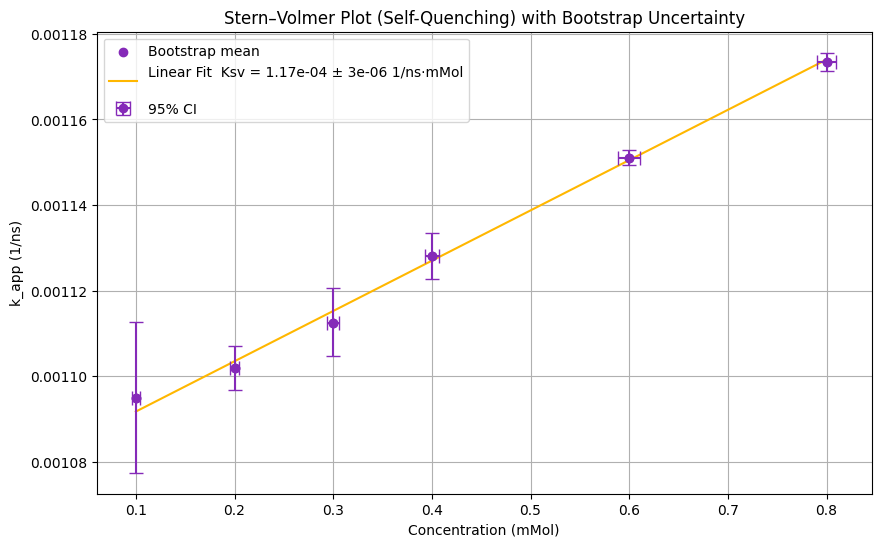

Chi-squared: 0.453
Reduced Chi-squared: 0.113


In [17]:
# Array prep
# Concentrations (BZ08 → 0.8 mM … BZ01 → 0.1 mM)
concentrations = np.array([0.8, 0.6, 0.4, 0.3, 0.2, 0.1])
tau_values = np.array([852.22356, 868.76250, 886.48941, 898.85662, 907.50005, 913.34809])
tau_std_values = np.array([0.80758, 0.68813, 2.17208, 3.27438, 2.18130, 7.50122])

# Tau 95% CI low/high (ns)
tau_CI_low  = np.array([850.65059, 867.41159, 882.20551, 892.43311, 903.21945, 898.70783])
tau_CI_high = np.array([853.80531, 870.10510, 890.74130, 905.24706, 911.80480, 928.08607])

# k_app = 1/tau with propagated uncertainties
k_app        = 1 / tau_values
k_app_SE     = tau_std_values / (tau_values**2)
k_app_CI_low = 1 / tau_CI_high
k_app_CI_high= 1 / tau_CI_low

#conc_err = np.array([0.01, 0.075, 0.08, 0.075, 0.067, 0.1])
conc_err = np.array([0.010,0.011,0.007, 0.006, 0.005, 0.004])

# ── Slope & intercept via np.polyfit with covariance ──────────────────────────
# Using k_app_SE as weights (w = 1/sigma) for weighted least squares
weights = 1 / k_app_SE  # inverse-sigma weighting

coeff, cov = np.polyfit(concentrations, k_app, 1, w=weights, cov=True)
k_sv_slope  = coeff[0]
intercept   = coeff[1]

# Standard errors directly from the covariance matrix diagonal
k_sv_slope_err  = np.sqrt(cov[0, 0])
intercept_err   = np.sqrt(cov[1, 1])

# ── Bootstrap uncertainty cross-check ─────────────────────────────────────────
n_boot = 10_000
rng = np.random.default_rng(42)

boot_slopes     = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)

for i in range(n_boot):
    # Resample k_app values within their SE (Gaussian noise)
    k_boot = k_app + rng.normal(0, k_app_SE, size=len(k_app))
    c_boot, _ = np.polyfit(concentrations, k_boot, 1, cov=False), None
    # polyfit returns array; unpack
    c_boot = np.polyfit(concentrations, k_boot, 1)
    boot_slopes[i]     = c_boot[0]
    boot_intercepts[i] = c_boot[1]

boot_slope_std     = np.std(boot_slopes,     ddof=1)
boot_intercept_std = np.std(boot_intercepts, ddof=1)

# 95% CI from bootstrap percentiles
slope_CI     = np.percentile(boot_slopes,     [2.5, 97.5])
intercept_CI = np.percentile(boot_intercepts, [2.5, 97.5])

# ── Print results ──────────────────────────────────────────────────────────────
print("=== Weighted polyfit (covariance matrix) ===")
print(f"  Ksv (slope)  : {k_sv_slope:.5e}  ±  {k_sv_slope_err:.5e}  1/ns·mM")
print(f"  k1 (intercept): {intercept:.5e}  ±  {intercept_err:.5e}  1/ns")

print("\n=== Bootstrap cross-check (n=10,000) ===")
print(f"  Ksv  : {np.mean(boot_slopes):.5e}  ±  {boot_slope_std:.5e}  "
      f"| 95% CI [{slope_CI[0]:.5e}, {slope_CI[1]:.5e}]")
print(f"  k1   : {np.mean(boot_intercepts):.5e}  ±  {boot_intercept_std:.5e}  "
      f"| 95% CI [{intercept_CI[0]:.5e}, {intercept_CI[1]:.5e}]")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

plt.scatter(concentrations, k_app, color='#852AB8', label='Bootstrap mean', zorder=5)
plt.errorbar(
    concentrations, k_app,
    xerr=conc_err,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o', color='#852AB8', capsize=5, label='95% CI', zorder=4
)

x_fit = np.linspace(concentrations.min(), concentrations.max(), 100)
plt.plot(x_fit, np.polyval(coeff, x_fit), color='#FFB700',
         label=(f'Linear Fit  Ksv = {k_sv_slope:.2e} ± {k_sv_slope_err:.0e} 1/ns·mMol\n'))
                #f'            k1  = {intercept:.4e} ± {intercept_err:.1e} 1/ns'))

plt.xlabel("Concentration (mMol)")
plt.ylabel("k_app (1/ns)")
plt.title("Stern–Volmer Plot (Self-Quenching) with Bootstrap Uncertainty")
plt.grid(True)
plt.legend()

plt.savefig(
    "/content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/SelfQuenching_SternVolmer.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

# Use symmetric errors from CI for chi-square
k_app_sigma = (k_app_CI_high - k_app_CI_low) / 2

# Model predictions
k_fit = np.polyval(coeff, concentrations)

# Chi-squared
chi2 = np.sum(((k_app - k_fit) / k_app_sigma)**2)

# Degrees of freedom: N - number of parameters (slope + intercept = 2)
dof = len(concentrations) - 2

# Reduced chi-squared
chi2_red = chi2 / dof

print(f"Chi-squared: {chi2:.3f}")
print(f"Reduced Chi-squared: {chi2_red:.3f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 6 CSV files:
  2026-02-10 12-05-10 TA BZ04.csv
  2026-02-10 12-14-03 TA BZ03.csv
  2026-02-17 12-00-30 TA BZ08 THIRD .csv
  2026-02-17 12-19-17 TA BZ06 NEW.csv
  2026-02-17 12-46-19 TA BZ01 THIRD .csv
  NEW 2026-02-10 16-14-02 TA BZ02.csv

Matched 6 samples:
  2026-02-17 12-46-19 TA BZ01 THIRD   →  0.1 mM
  NEW 2026-02-10 16-14-02 TA BZ02  →  0.2 mM
  2026-02-10 12-14-03 TA BZ03  →  0.3 mM
  2026-02-10 12-05-10 TA BZ04  →  0.4 mM
  2026-02-17 12-19-17 TA BZ06 NEW  →  0.6 mM
  2026-02-17 12-00-30 TA BZ08 THIRD   →  0.8 mM

  2026-02-17 12-46-19 TA BZ01 THIRD   (0.1 mM)
  489 points  (t = 120.00 … 5000.00 ns)
  Analysis A — single-exp fit + bootstrapping …
  τ = 889.5671 ± 2.8468 ns  95% CI [884.0467, 895.2185]  χ²ᵣ = 1.0062
  Analysis B — ILT (tikhonov) …
  Mean τ = 1062.336 ns  Peak τ = 941.990 ns  χ²ᵣ = 4.5313


/tmp/ipykernel_9114/1995785550.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


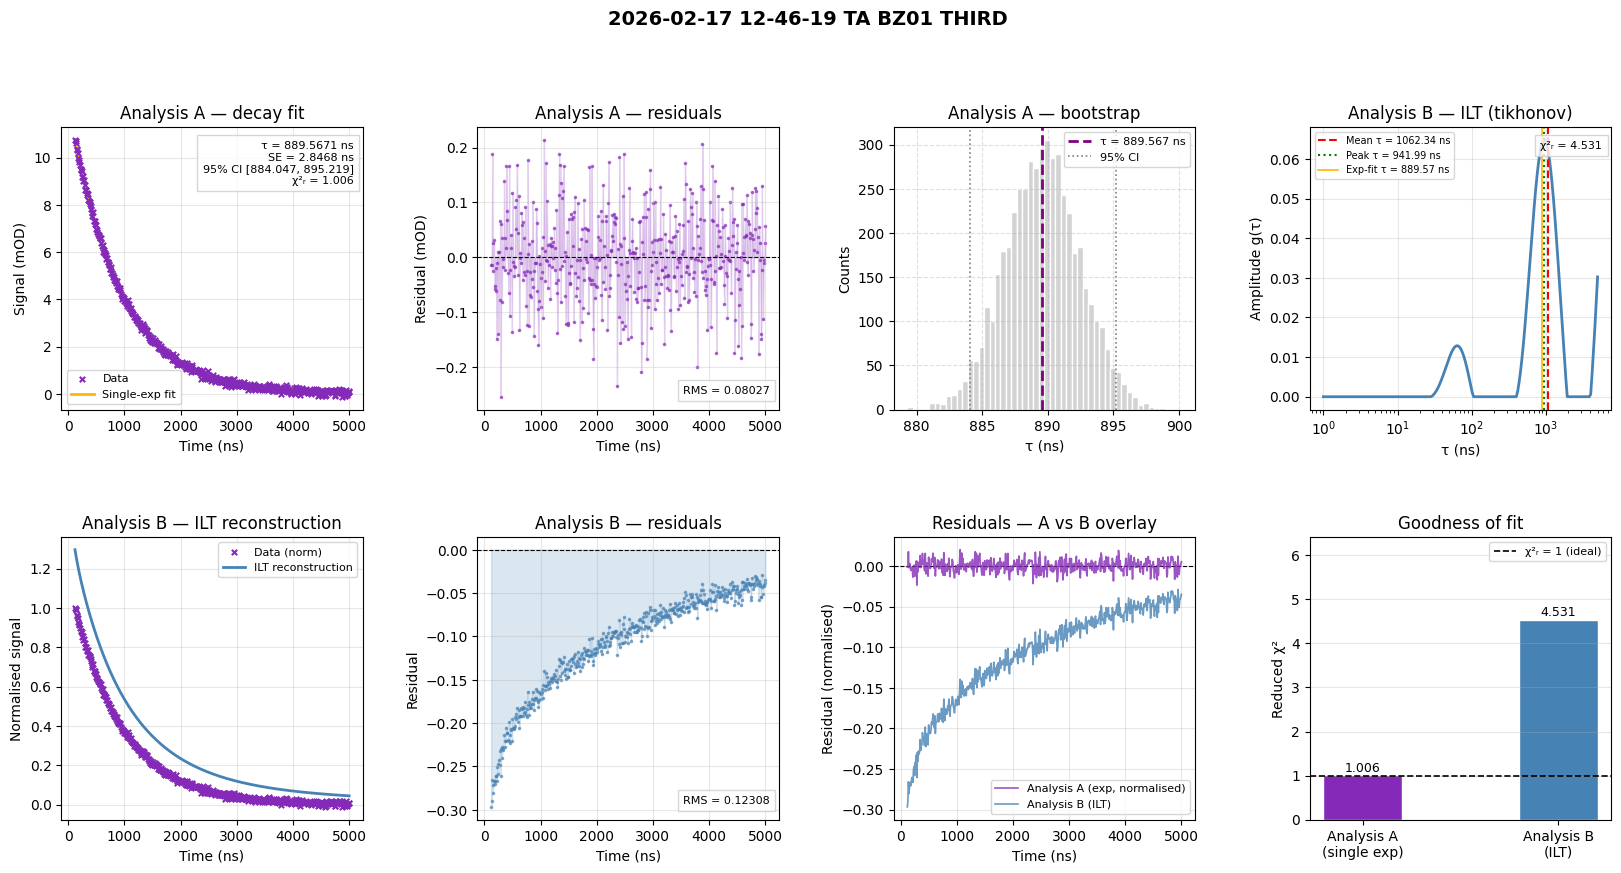

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/2026-02-17 12-46-19 TA BZ01 THIRD _full_analysis.png

  ── Residual diagnostics for 2026-02-17 12-46-19 TA BZ01 THIRD  ──
  Analysis A  χ²ᵣ = 1.0062   RMS = 0.08027 mOD
  Analysis B  χ²ᵣ = 4.5313   RMS = 0.12308
  → χ²ᵣ near 1: single-exp fit looks good.
  → A and B perform similarly — single-exponential model is appropriate.

  NEW 2026-02-10 16-14-02 TA BZ02  (0.2 mM)
  489 points  (t = 120.00 … 5000.00 ns)
  Analysis A — single-exp fit + bootstrapping …
  τ = 907.5001 ± 2.1714 ns  95% CI [903.2660, 911.8433]  χ²ᵣ = 1.0062
  Analysis B — ILT (tikhonov) …
  Mean τ = 1050.316 ns  Peak τ = 902.523 ns  χ²ᵣ = 3.9235


/tmp/ipykernel_9114/1995785550.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


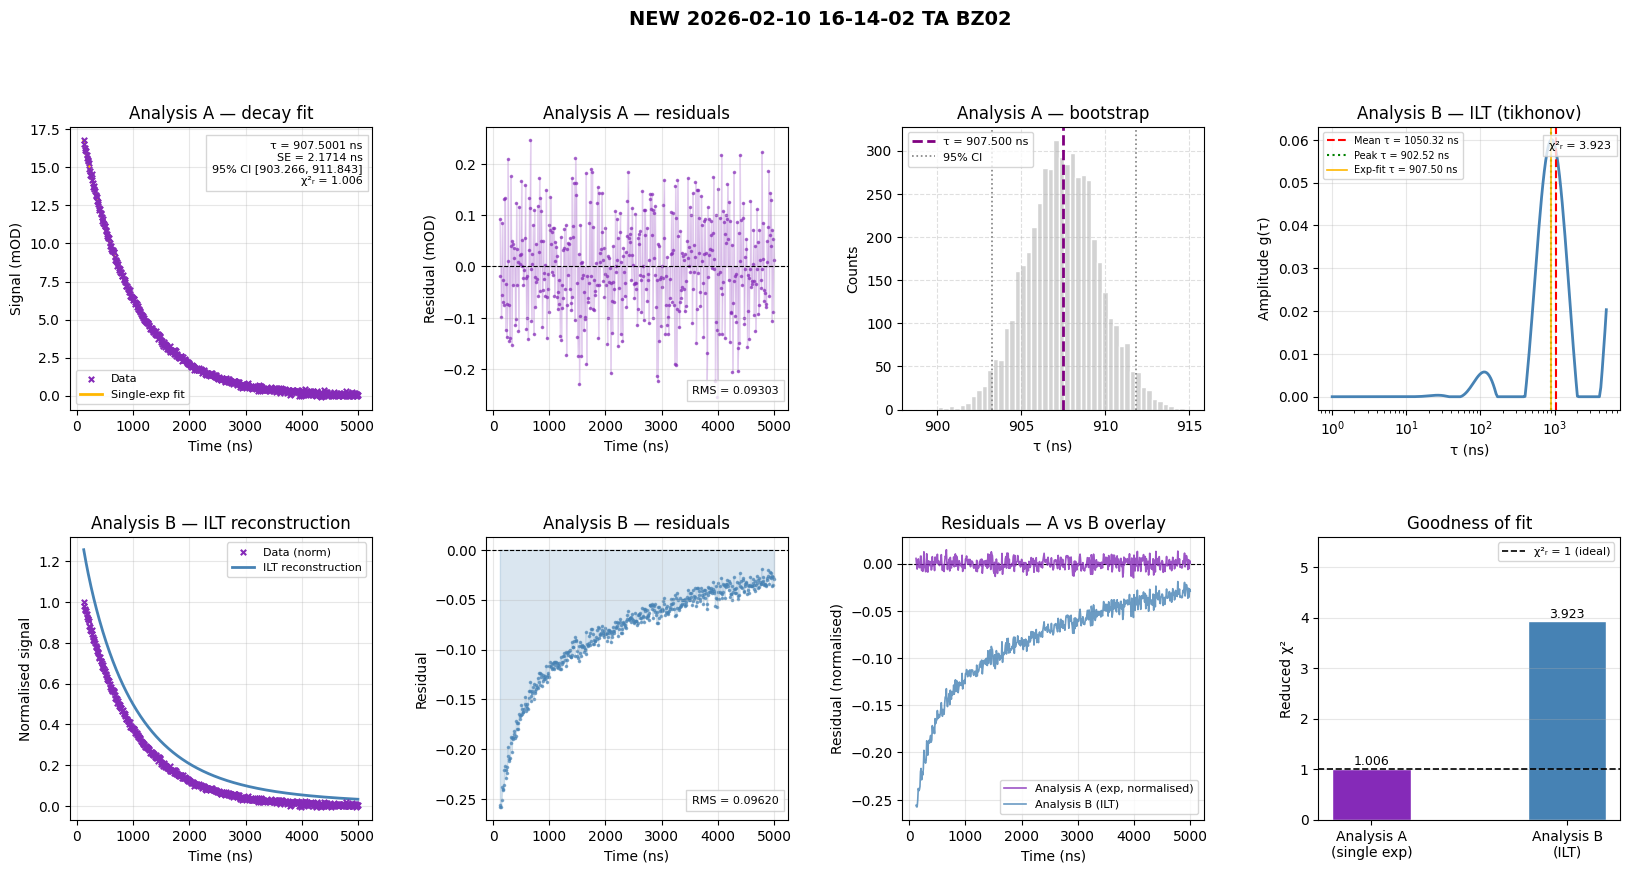

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/NEW 2026-02-10 16-14-02 TA BZ02_full_analysis.png

  ── Residual diagnostics for NEW 2026-02-10 16-14-02 TA BZ02 ──
  Analysis A  χ²ᵣ = 1.0062   RMS = 0.09303 mOD
  Analysis B  χ²ᵣ = 3.9235   RMS = 0.09620
  → χ²ᵣ near 1: single-exp fit looks good.
  → A and B perform similarly — single-exponential model is appropriate.

  2026-02-10 12-14-03 TA BZ03  (0.3 mM)
  489 points  (t = 120.00 … 5000.00 ns)
  Analysis A — single-exp fit + bootstrapping …
  τ = 898.8566 ± 3.2283 ns  95% CI [892.6011, 905.3042]  χ²ᵣ = 1.0062
  Analysis B — ILT (tikhonov) …
  Mean τ = 954.042 ns  Peak τ = 864.710 ns  χ²ᵣ = 3.2566


/tmp/ipykernel_9114/1995785550.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


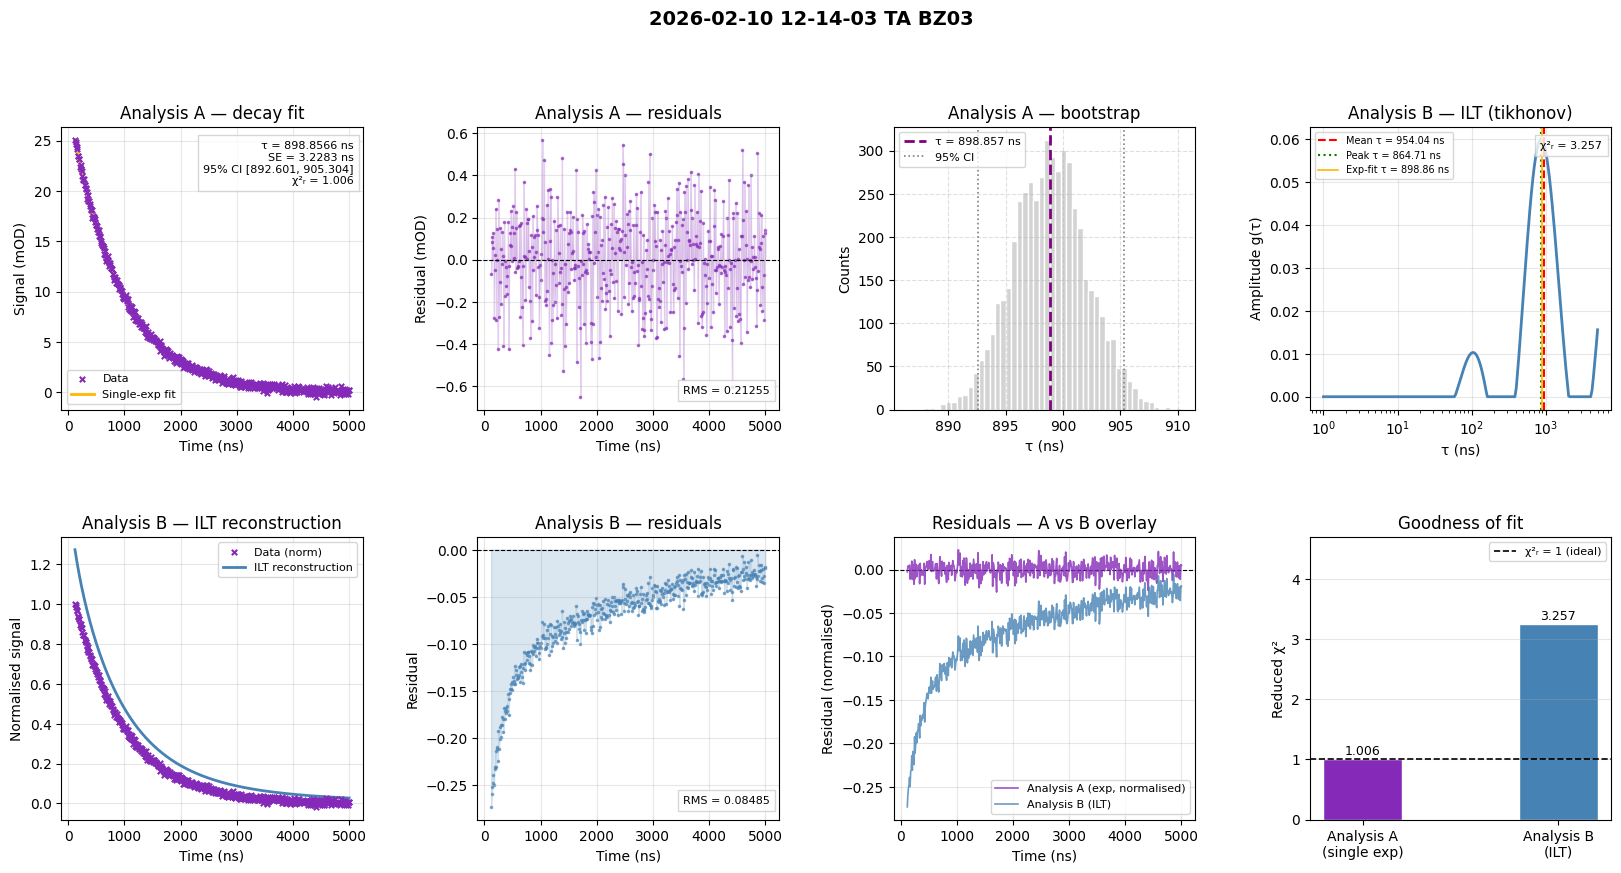

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/2026-02-10 12-14-03 TA BZ03_full_analysis.png

  ── Residual diagnostics for 2026-02-10 12-14-03 TA BZ03 ──
  Analysis A  χ²ᵣ = 1.0062   RMS = 0.21255 mOD
  Analysis B  χ²ᵣ = 3.2566   RMS = 0.08485
  → χ²ᵣ near 1: single-exp fit looks good.
  → A and B perform similarly — single-exponential model is appropriate.

  2026-02-10 12-05-10 TA BZ04  (0.4 mM)
  489 points  (t = 120.00 … 5000.00 ns)
  Analysis A — single-exp fit + bootstrapping …
  τ = 886.4894 ± 2.1688 ns  95% CI [882.2116, 890.7633]  χ²ᵣ = 1.0062
  Analysis B — ILT (tikhonov) …
  Mean τ = 1119.350 ns  Peak τ = 941.990 ns  χ²ᵣ = 4.6705


/tmp/ipykernel_9114/1995785550.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


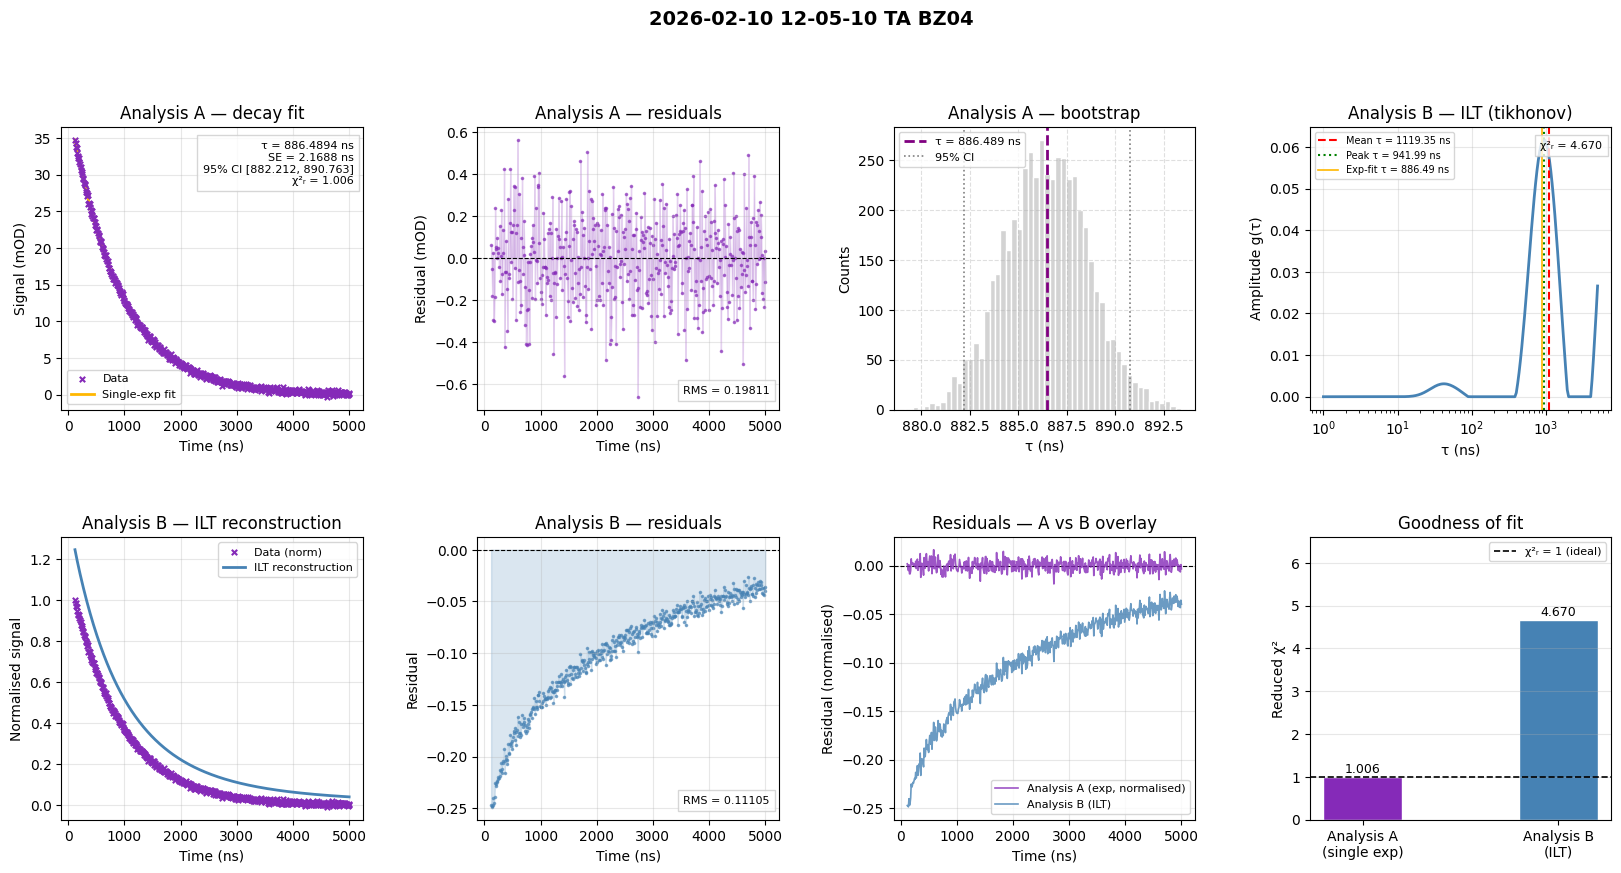

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/2026-02-10 12-05-10 TA BZ04_full_analysis.png

  ── Residual diagnostics for 2026-02-10 12-05-10 TA BZ04 ──
  Analysis A  χ²ᵣ = 1.0062   RMS = 0.19811 mOD
  Analysis B  χ²ᵣ = 4.6705   RMS = 0.11105
  → χ²ᵣ near 1: single-exp fit looks good.
  → A and B perform similarly — single-exponential model is appropriate.

  2026-02-17 12-19-17 TA BZ06 NEW  (0.6 mM)
  489 points  (t = 120.00 … 5000.00 ns)
  Analysis A — single-exp fit + bootstrapping …
  τ = 868.7625 ± 0.6962 ns  95% CI [867.4208, 870.1280]  χ²ᵣ = 1.0062
  Analysis B — ILT (tikhonov) …
  Mean τ = 1117.611 ns  Peak τ = 902.523 ns  χ²ᵣ = 4.1641


/tmp/ipykernel_9114/1995785550.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


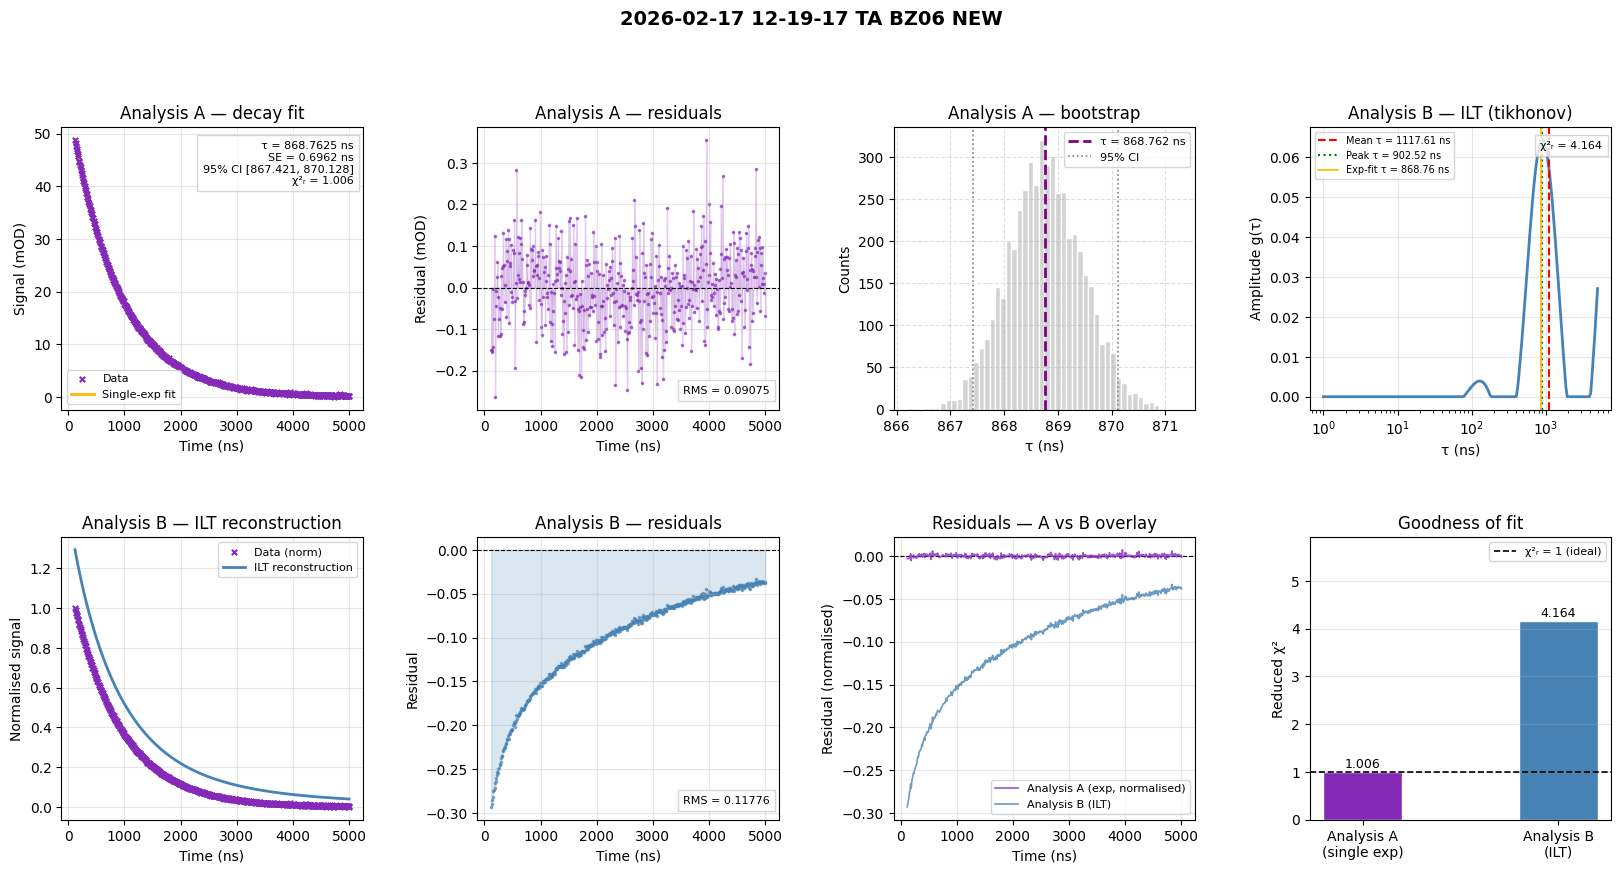

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/2026-02-17 12-19-17 TA BZ06 NEW_full_analysis.png

  ── Residual diagnostics for 2026-02-17 12-19-17 TA BZ06 NEW ──
  Analysis A  χ²ᵣ = 1.0062   RMS = 0.09075 mOD
  Analysis B  χ²ᵣ = 4.1641   RMS = 0.11776
  → χ²ᵣ near 1: single-exp fit looks good.
  → A and B perform similarly — single-exponential model is appropriate.

  2026-02-17 12-00-30 TA BZ08 THIRD   (0.8 mM)
  489 points  (t = 120.00 … 5000.00 ns)
  Analysis A — single-exp fit + bootstrapping …
  τ = 852.2236 ± 0.8035 ns  95% CI [850.6702, 853.7994]  χ²ᵣ = 1.0062
  Analysis B — ILT (tikhonov) …
  Mean τ = 1026.510 ns  Peak τ = 864.710 ns  χ²ᵣ = 3.6463


/tmp/ipykernel_9114/1995785550.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


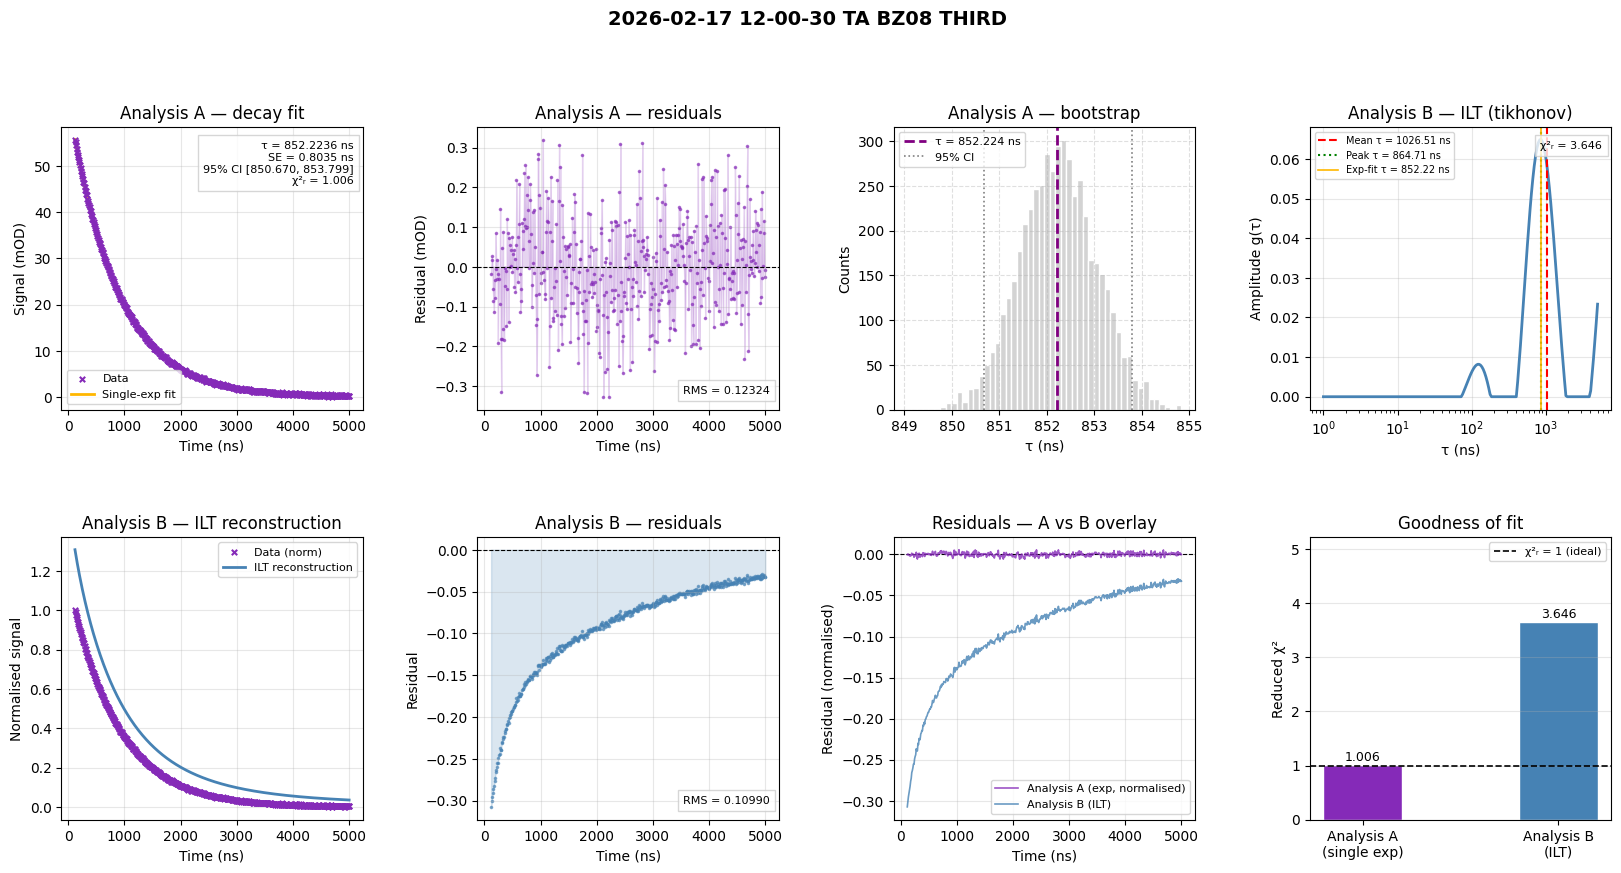

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/2026-02-17 12-00-30 TA BZ08 THIRD _full_analysis.png

  ── Residual diagnostics for 2026-02-17 12-00-30 TA BZ08 THIRD  ──
  Analysis A  χ²ᵣ = 1.0062   RMS = 0.12324 mOD
  Analysis B  χ²ᵣ = 3.6463   RMS = 0.10990
  → χ²ᵣ near 1: single-exp fit looks good.
  → A and B perform similarly — single-exponential model is appropriate.

  ILT overlay


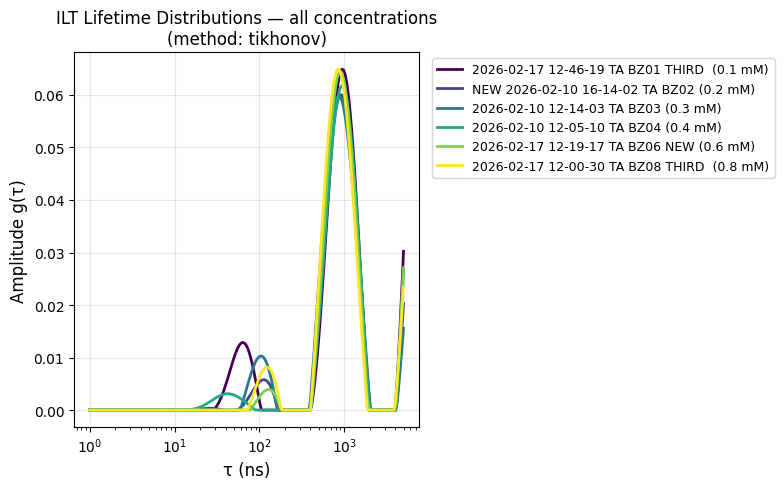

  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/ILT_overlay.png

  Stern–Volmer


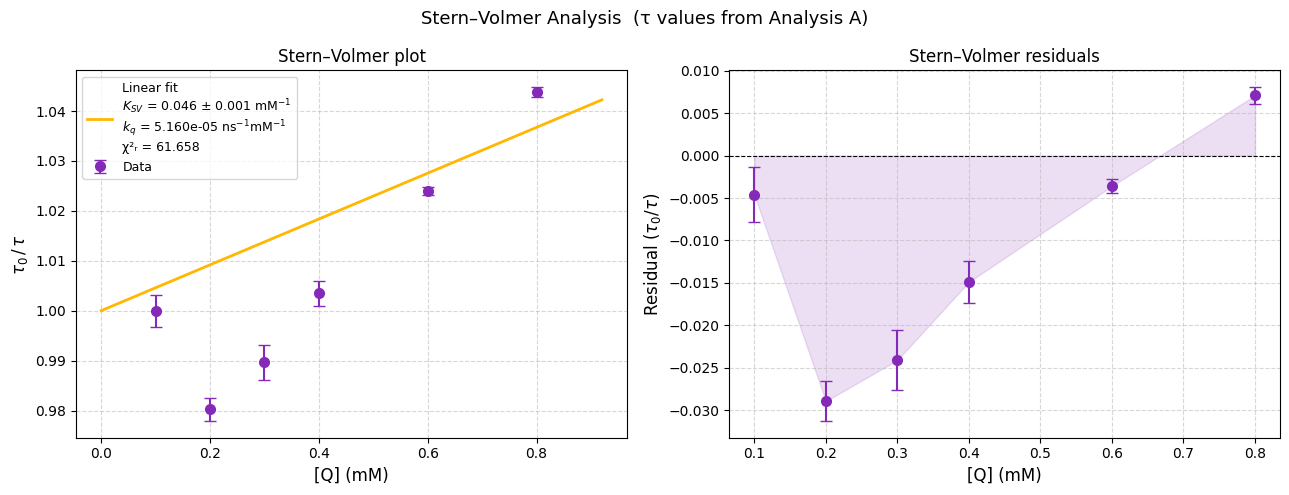


Stern–Volmer results:
  τ₀  = 889.5671 ns  (2026-02-17 12-46-19 TA BZ01 THIRD )
  K_SV = 0.0459 ± 0.0009 mM⁻¹
  k_q  = 5.1603e-05 ns⁻¹ mM⁻¹
  SV fit χ²ᵣ = 61.6582
  Saved → /content/drive/My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026/SternVolmer_auto.png

  SUMMARY TABLE
                            Sample  [Q] (mM)  τ_exp (ns)  τ_exp SE (ns)  ILT peak τ (ns)  ILT mean τ (ns)
2026-02-17 12-46-19 TA BZ01 THIRD        0.1    889.5671         2.8468         941.9899        1062.3361
   NEW 2026-02-10 16-14-02 TA BZ02       0.2    907.5001         2.1714         902.5233        1050.3158
       2026-02-10 12-14-03 TA BZ03       0.3    898.8566         3.2283         864.7103         954.0417
       2026-02-10 12-05-10 TA BZ04       0.4    886.4894         2.1688         941.9899        1119.3497
   2026-02-17 12-19-17 TA BZ06 NEW       0.6    868.7625         0.6962         902.5233        1117.6112
2026-02-17 12-00-30 TA BZ08 THIRD        0.8    852.2236         0.8035         86

In [ ]:
# ============================================================
# FULL AUTOMATED TRAS ANALYSIS
# ── Analysis A: Single-exponential fit + bootstrapping
# ── Analysis B: Inverse Laplace Transform (Tikhonov)
# ── Residuals + chi-squared for both
# ── Stern-Volmer from Analysis A taus
# ── Loops all CSVs automatically
# ============================================================

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit, minimize, nnls

from google.colab import drive
rootpathdrive = '/content/drive'
drive.mount(rootpathdrive)

# ============================================================
# !! USER SETTINGS — edit these !!
# ============================================================

pathTRAS = rootpathdrive + '/' + 'My Drive/Year 3 Lab/TRAS/TRAS/Self_Quenching_17Feb2026'

# Key = substring that appears in the filename, value = concentration in mM.
# Order from most specific to least specific to avoid partial matches
# (e.g. 'BZC01' must come before 'BZC1' so 'BZC01' files are not
# matched by the 'BZC1' key).
CONCENTRATION_MAP = {
    'BZ04':  0.4,
    'BZ03':  0.3,
    'BZ08':  0.8,
    'BZ06':  0.6,
    'BZ01':  0.1,
    'BZ02':  0.2,
}

N_BOOT     = 5000   # bootstrap iterations

# ILT settings
ILT_METHOD = 'tikhonov'   # 'tikhonov' | 'nnls' | 'maxent'
LAMBDA_REG = 0.01
# TAU_MIN    = 0.1    # ns — lower bound of lifetime grid
# TAU_MAX    = 50.0   # ns — upper bound of lifetime grid
# N_TAU      = 100    # number of grid points

TAU_MIN = 1.0    # ns
TAU_MAX = 5000.0 # ns — must exceed your longest decay
N_TAU   = 200    # more points to cover the wider range
# ============================================================
# SECTION 1 — Load & preprocess
# ============================================================

def load_csv(filepath):
    """
    Read a two-column semicolon-separated CSV (time; signal),
    drop any header row, cast to float, and crop from the peak onward.
    """
    df = pd.read_csv(filepath, sep=";", header=None, names=["time", "signal"])
    df = df[pd.to_numeric(df["time"], errors="coerce").notna()].reset_index(drop=True)
    df = df.astype(float)
    idx_peak = df["signal"].idxmax()
    df = df.loc[idx_peak:].reset_index(drop=True)
    return df["time"].to_numpy(), df["signal"].to_numpy()


# ============================================================
# SECTION 2 — Analysis A: single-exp fit + bootstrap
# ============================================================

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def chi2_reduced_exp(time, signal, popt, n_params=3):
    """
    Reduced chi-squared for the single-exponential fit.
    Noise sigma is estimated from the RMS of the fit residuals.
    A value close to 1 means a good fit; well above 1 suggests
    systematic structure remains in the residuals.
    """
    y_fit     = exp_decay(time, *popt)
    residuals = signal - y_fit
    sigma     = np.std(residuals)
    if sigma == 0:
        return np.nan
    chi2 = np.sum((residuals / sigma) ** 2)
    dof  = len(signal) - n_params
    return chi2 / dof


def fit_single_exp(time, signal, n_boot=N_BOOT):
    """
    Fit a single exponential decay, then bootstrap the residuals
    to obtain uncertainty on tau.
    """
    x, y = time, signal
    p0     = [y.max() - y.min(), (x.max() - x.min()) / 5, y.min()]
    bounds = ([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf])

    popt, _ = curve_fit(exp_decay, x, y, p0=p0, bounds=bounds, maxfev=10000)
    A, tau, C = popt

    y_fit     = exp_decay(x, *popt)
    residuals = y - y_fit

    # Bootstrap
    tau_boot = []
    for _ in range(n_boot):
        y_boot = y_fit + np.random.choice(residuals, size=len(residuals), replace=True)
        try:
            p_b, _ = curve_fit(exp_decay, x, y_boot, p0=popt, bounds=bounds, maxfev=5000)
            tau_boot.append(p_b[1])
        except RuntimeError:
            continue

    tau_boot        = np.array(tau_boot)
    tau_std         = np.std(tau_boot)
    ci_low, ci_high = np.percentile(tau_boot, [2.5, 97.5])
    chi2_red        = chi2_reduced_exp(x, y, popt)

    return dict(
        A=A, tau=tau, C=C,
        y_fit=y_fit, residuals=residuals,
        tau_std=tau_std, ci_low=ci_low, ci_high=ci_high,
        tau_boot=tau_boot,
        chi2_red=chi2_red,
    )


# ============================================================
# SECTION 3 — Analysis B: Inverse Laplace Transform
# ============================================================

def build_kernel(t_data, tau_grid):
    """Kernel matrix K[i,j] = exp(-t_i / tau_j), vectorised."""
    return np.exp(-t_data[:, np.newaxis] / tau_grid[np.newaxis, :])


def ilt_tikhonov(t_data, signal, tau_grid, lam=LAMBDA_REG):
    """Tikhonov (L2) regularised ILT."""
    K   = build_kernel(t_data, tau_grid)
    KtK = K.T @ K
    reg = lam * np.eye(len(tau_grid))
    try:
        g = np.linalg.solve(KtK + reg, K.T @ signal)
    except np.linalg.LinAlgError:
        g = np.linalg.pinv(KtK + reg) @ (K.T @ signal)
    return np.maximum(g, 0)


def ilt_nnls(t_data, signal, tau_grid):
    """Non-negative least squares ILT."""
    K    = build_kernel(t_data, tau_grid)
    g, _ = nnls(K, signal)
    return g


def ilt_maxent(t_data, signal, tau_grid, alpha=0.1, max_iter=200):
    """Maximum entropy ILT."""
    K = build_kernel(t_data, tau_grid)

    def objective(g):
        return (np.sum((signal - K @ g) ** 2)
                + alpha * np.sum(g * np.log(g + 1e-10)))

    def gradient(g):
        return (-2 * K.T @ (signal - K @ g)
                + alpha * (np.log(g + 1e-10) + 1))

    g0     = np.ones(len(tau_grid)) / len(tau_grid)
    result = minimize(objective, g0, jac=gradient, method='L-BFGS-B',
                      bounds=[(0, None)] * len(tau_grid),
                      options={'maxiter': max_iter})
    return result.x


def chi2_reduced_ilt(signal_norm, reconstructed, n_params_eff=10):
    """
    Reduced chi-squared for the ILT reconstruction.
    n_params_eff is a conservative effective DOF for Tikhonov
    (the true value depends on lambda and the data).
    """
    residuals = signal_norm - reconstructed
    sigma     = np.std(residuals)
    if sigma == 0:
        return np.nan
    chi2 = np.sum((residuals / sigma) ** 2)
    dof  = len(signal_norm) - n_params_eff
    return chi2 / dof


def run_ilt(time, signal, method=ILT_METHOD):
    """Normalise signal, run ILT, compute diagnostics."""
    sig_norm = signal / np.max(signal[:10])
    tau_grid = np.logspace(np.log10(TAU_MIN), np.log10(TAU_MAX), N_TAU)

    if method == 'tikhonov':
        g = ilt_tikhonov(time, sig_norm, tau_grid)
    elif method == 'nnls':
        g = ilt_nnls(time, sig_norm, tau_grid)
    elif method == 'maxent':
        g = ilt_maxent(time, sig_norm, tau_grid)
    else:
        raise ValueError("method must be 'tikhonov', 'nnls', or 'maxent'")

    K             = build_kernel(time, tau_grid)
    reconstructed = K @ g
    ilt_residuals = sig_norm - reconstructed

    total_weight = np.sum(g)
    mean_tau     = np.sum(tau_grid * g) / total_weight if total_weight > 0 else 0
    peak_tau     = tau_grid[np.argmax(g)]
    chi2_red     = chi2_reduced_ilt(sig_norm, reconstructed)

    return dict(
        tau_grid=tau_grid, g=g,
        reconstructed=reconstructed, residuals=ilt_residuals,
        sig_norm=sig_norm,
        mean_tau=mean_tau, peak_tau=peak_tau,
        chi2_red=chi2_red,
    )


# ============================================================
# SECTION 4 — Per-sample 2×4 figure
#
# Row 1: decay+fit | exp residuals | bootstrap hist | ILT distribution
# Row 2: ILT recon | ILT residuals | residual overlay | chi2 bar
# ============================================================

def plot_sample(name, time, signal, fit, ilt, save_dir):

    fig = plt.figure(figsize=(20, 9))
    fig.suptitle(name, fontsize=14, fontweight='bold', y=1.01)
    gs   = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.38)
    axes = [[fig.add_subplot(gs[r, c]) for c in range(4)] for r in range(2)]

    x         = time
    y         = signal
    y_fit_exp = fit['y_fit']
    res_exp   = fit['residuals']
    sig_norm  = ilt['sig_norm']
    recon     = ilt['reconstructed']
    res_ilt   = ilt['residuals']
    x_smooth  = np.linspace(x.min(), x.max(), 1000)

    # ── ROW 1 ───────────────────────────────────────────────

    # (0,0) Decay data + single-exp fit
    ax = axes[0][0]
    ax.scatter(x, y, marker='x', color='#852AB8', s=15, label='Data', zorder=3)
    ax.plot(x_smooth,
            exp_decay(x_smooth, fit['A'], fit['tau'], fit['C']),
            color='#FFB700', linewidth=2, label='Single-exp fit')
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Signal (mOD)")
    ax.set_title("Analysis A — decay fit")
    ax.text(0.97, 0.95,
            f"τ = {fit['tau']:.4f} ns\n"
            f"SE = {fit['tau_std']:.4f} ns\n"
            f"95% CI [{fit['ci_low']:.3f}, {fit['ci_high']:.3f}]\n"
            f"χ²ᵣ = {fit['chi2_red']:.3f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ccc'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (0,1) Single-exp residuals
    ax = axes[0][1]
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.scatter(x, res_exp, marker='.', color='#852AB8', s=10, alpha=0.6)
    ax.fill_between(x, res_exp, alpha=0.2, color='#852AB8')
    rms_exp = np.sqrt(np.mean(res_exp**2))
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Residual (mOD)")
    ax.set_title("Analysis A — residuals")
    ax.text(0.97, 0.05, f"RMS = {rms_exp:.5f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ccc'))
    ax.grid(True, alpha=0.3)

    # (0,2) Bootstrap histogram
    ax = axes[0][2]
    ax.hist(fit['tau_boot'], bins=50, color='#D3D3D3',
            edgecolor='white', linewidth=1.0)
    ax.axvline(fit['tau'], color='purple', linestyle='--', linewidth=2,
               label=f"τ = {fit['tau']:.3f} ns")
    ax.axvline(fit['ci_low'],  color='gray', linestyle=':', linewidth=1.2)
    ax.axvline(fit['ci_high'], color='gray', linestyle=':', linewidth=1.2,
               label="95% CI")
    ax.set_xlabel("τ (ns)")
    ax.set_ylabel("Counts")
    ax.set_title("Analysis A — bootstrap")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

    # (0,3) ILT lifetime distribution
    ax = axes[0][3]
    ax.semilogx(ilt['tau_grid'], ilt['g'], color='steelblue', linewidth=2)
    ax.axvline(ilt['mean_tau'], color='red',     linestyle='--', linewidth=1.5,
               label=f"Mean τ = {ilt['mean_tau']:.2f} ns")
    ax.axvline(ilt['peak_tau'], color='green',   linestyle=':',  linewidth=1.5,
               label=f"Peak τ = {ilt['peak_tau']:.2f} ns")
    ax.axvline(fit['tau'],      color='#FFB700', linestyle='-',  linewidth=1.2,
               label=f"Exp-fit τ = {fit['tau']:.2f} ns")
    ax.set_xlabel("τ (ns)")
    ax.set_ylabel("Amplitude g(τ)")
    ax.set_title(f"Analysis B — ILT ({ILT_METHOD})")
    ax.text(0.97, 0.95, f"χ²ᵣ = {ilt['chi2_red']:.3f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ccc'))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # ── ROW 2 ───────────────────────────────────────────────

    # (1,0) ILT reconstruction vs normalised data
    ax = axes[1][0]
    ax.scatter(x, sig_norm, marker='x', color='#852AB8', s=15,
               label='Data (norm)', zorder=3)
    ax.plot(x, recon, color='steelblue', linewidth=2, label='ILT reconstruction')
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Normalised signal")
    ax.set_title("Analysis B — ILT reconstruction")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (1,1) ILT residuals
    ax = axes[1][1]
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.scatter(x, res_ilt, marker='.', color='steelblue', s=10, alpha=0.6)
    ax.fill_between(x, res_ilt, alpha=0.2, color='steelblue')
    rms_ilt = np.sqrt(np.mean(res_ilt**2))
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Residual")
    ax.set_title("Analysis B — residuals")
    ax.text(0.97, 0.05, f"RMS = {rms_ilt:.5f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ccc'))
    ax.grid(True, alpha=0.3)

    # (1,2) Residuals overlay for direct comparison
    # Normalise exp residuals to the same scale as ILT residuals
    ax = axes[1][2]
    res_exp_norm = res_exp / np.max(np.abs(signal[:10]))
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.plot(x, res_exp_norm, color='#852AB8', linewidth=1.2, alpha=0.8,
            label='Analysis A (exp, normalised)')
    ax.plot(x, res_ilt, color='steelblue', linewidth=1.2, alpha=0.8,
            label='Analysis B (ILT)')
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Residual (normalised)")
    ax.set_title("Residuals — A vs B overlay")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (1,3) Chi-squared bar comparison
    ax = axes[1][3]
    labels = ['Analysis A\n(single exp)', 'Analysis B\n(ILT)']
    chi2s  = [fit['chi2_red'], ilt['chi2_red']]
    colors = ['#852AB8', 'steelblue']
    bars   = ax.bar(labels, chi2s, color=colors, width=0.4, edgecolor='white')
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2,
               label='χ²ᵣ = 1 (ideal)')
    for bar, val in zip(bars, chi2s):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel("Reduced χ²")
    ax.set_title("Goodness of fit")
    ax.set_ylim(0, max(chi2s) * 1.35 + 0.3)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(save_dir, f"{name}_full_analysis.png")
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")

    # ── Interpretation hint printed to console ───────────────
    print(f"\n  ── Residual diagnostics for {name} ──")
    print(f"  Analysis A  χ²ᵣ = {fit['chi2_red']:.4f}   RMS = {rms_exp:.5f} mOD")
    print(f"  Analysis B  χ²ᵣ = {ilt['chi2_red']:.4f}   RMS = {rms_ilt:.5f}")

    if fit['chi2_red'] < 1.5:
        print("  → χ²ᵣ near 1: single-exp fit looks good.")
    elif fit['chi2_red'] < 3.0:
        print("  → Mild misfit: check residual plot for systematic curvature.")
    else:
        print("  ⚠ Large χ²ᵣ: residuals likely structured — consider multi-exp or ILT.")

    if ilt['chi2_red'] < fit['chi2_red'] * 0.9:
        print("  → ILT reconstructs data noticeably better than single-exp.")
    else:
        print("  → A and B perform similarly — single-exponential model is appropriate.")


# ============================================================
# SECTION 5 — ILT overlay across all concentrations
# ============================================================

def plot_ilt_overlay(ilt_results, save_dir):
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(ilt_results)))

    for (name, conc, ilt), col in zip(ilt_results, colors):
        ax.semilogx(ilt['tau_grid'], ilt['g'], color=col, linewidth=2,
                    label=f'{name} ({conc} mM)')

    ax.set_xlabel('τ (ns)', fontsize=12)
    ax.set_ylabel('Amplitude g(τ)', fontsize=12)
    ax.set_title(
        f'ILT Lifetime Distributions — all concentrations\n(method: {ILT_METHOD})',
        fontsize=12)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(save_dir, 'ILT_overlay.png')
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")


# ============================================================
# SECTION 6 — Stern-Volmer (built from Analysis A taus)
# ============================================================

def plot_stern_volmer(sv_data, save_dir):
    """
    Plots tau0/tau vs [Q] with error bars, fits a linear
    Stern-Volmer model, and shows the SV residuals.
    tau0 is taken as the tau at the lowest quencher concentration.
    """
    sv_sorted = sorted(sv_data, key=lambda d: d['conc'])

    concs     = np.array([d['conc']    for d in sv_sorted])
    taus      = np.array([d['tau']     for d in sv_sorted])
    tau_err   = np.array([d['tau_std'] for d in sv_sorted])

    tau0      = taus[0]
    ratios    = tau0 / taus
    # Error propagation: sigma(tau0/tau) = (tau0/tau^2) * sigma_tau
    ratio_err = (tau0 / taus**2) * tau_err

    def sv_line(q, Ksv):
        return 1 + Ksv * q

    popt, pcov  = curve_fit(sv_line, concs, ratios,
                            sigma=ratio_err, absolute_sigma=True)
    Ksv         = popt[0]
    Ksv_err     = np.sqrt(pcov[0, 0])
    kq          = Ksv / tau0   # bimolecular quenching rate constant

    sv_fit_vals  = sv_line(concs, Ksv)
    sv_residuals = ratios - sv_fit_vals
    sv_chi2_red  = (np.sum((sv_residuals / ratio_err) ** 2)
                    / (len(concs) - 1))

    q_fit = np.linspace(0, concs.max() * 1.15, 200)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Stern–Volmer Analysis  (τ values from Analysis A)",
        fontsize=13)

    # Left: SV plot
    ax = axes[0]
    ax.errorbar(concs, ratios, yerr=ratio_err,
                fmt='o', color='#852AB8', markersize=7, capsize=4,
                label='Data', zorder=3)
    ax.plot(q_fit, sv_line(q_fit, Ksv), color='#FFB700', linewidth=2,
            label=(f'Linear fit\n'
                   f'$K_{{SV}}$ = {Ksv:.3f} ± {Ksv_err:.3f} mM$^{{-1}}$\n'
                   f'$k_q$ = {kq:.3e} ns$^{{-1}}$mM$^{{-1}}$\n'
                   f'χ²ᵣ = {sv_chi2_red:.3f}'))
    ax.set_xlabel('[Q] (mM)', fontsize=12)
    ax.set_ylabel(r'$\tau_0\,/\,\tau$', fontsize=12)
    ax.set_title('Stern–Volmer plot')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Right: SV residuals
    ax = axes[1]
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.errorbar(concs, sv_residuals, yerr=ratio_err,
                fmt='o', color='#852AB8', markersize=7, capsize=4)
    ax.fill_between(concs, sv_residuals, alpha=0.15, color='#852AB8')
    ax.set_xlabel('[Q] (mM)', fontsize=12)
    ax.set_ylabel(r'Residual ($\tau_0/\tau$)', fontsize=12)
    ax.set_title('Stern–Volmer residuals')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    out_path = os.path.join(save_dir, 'SternVolmer_auto.png')
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nStern–Volmer results:")
    print(f"  τ₀  = {tau0:.4f} ns  ({sv_sorted[0]['name']})")
    print(f"  K_SV = {Ksv:.4f} ± {Ksv_err:.4f} mM⁻¹")
    print(f"  k_q  = {kq:.4e} ns⁻¹ mM⁻¹")
    print(f"  SV fit χ²ᵣ = {sv_chi2_red:.4f}")
    print(f"  Saved → {out_path}")


# ============================================================
# SECTION 7 — MAIN LOOP
# ============================================================

# Discover CSV files
all_files = os.listdir(pathTRAS)
csv_files = sorted([f for f in all_files if f.endswith('.csv')])
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  {f}")

# Match files to concentrations
# Keys in CONCENTRATION_MAP are tested in definition order —
# put longer/more-specific keys first (already done above).
samples = []
for csv_file in csv_files:
    conc = None
    for key, val in CONCENTRATION_MAP.items():
        if key in csv_file:
            conc = val
            break
    if conc is None:
        print(f"  WARNING: no concentration match for '{csv_file}' — skipping.")
        continue
    samples.append((csv_file.replace('.csv', ''),
                    os.path.join(pathTRAS, csv_file),
                    conc))

samples = sorted(samples, key=lambda s: s[2])   # sort by concentration
print(f"\nMatched {len(samples)} samples:")
for name, _, conc in samples:
    print(f"  {name}  →  {conc} mM")

# Per-sample analysis
sv_data     = []
ilt_results = []

for name, filepath, conc in samples:
    print(f"\n{'='*62}")
    print(f"  {name}  ({conc} mM)")
    print(f"{'='*62}")

    time, signal = load_csv(filepath)
    print(f"  {len(time)} points  (t = {time[0]:.2f} … {time[-1]:.2f} ns)")

    print("  Analysis A — single-exp fit + bootstrapping …")
    fit = fit_single_exp(time, signal)
    print(f"  τ = {fit['tau']:.4f} ± {fit['tau_std']:.4f} ns  "
          f"95% CI [{fit['ci_low']:.4f}, {fit['ci_high']:.4f}]  "
          f"χ²ᵣ = {fit['chi2_red']:.4f}")

    print(f"  Analysis B — ILT ({ILT_METHOD}) …")
    ilt = run_ilt(time, signal)
    print(f"  Mean τ = {ilt['mean_tau']:.3f} ns  "
          f"Peak τ = {ilt['peak_tau']:.3f} ns  "
          f"χ²ᵣ = {ilt['chi2_red']:.4f}")

    plot_sample(name, time, signal, fit, ilt, pathTRAS)

    sv_data.append(dict(name=name, conc=conc,
                        tau=fit['tau'], tau_std=fit['tau_std']))
    ilt_results.append((name, conc, ilt))

# ILT overlay
print(f"\n{'='*62}\n  ILT overlay\n{'='*62}")
plot_ilt_overlay(ilt_results, pathTRAS)

# Stern-Volmer
print(f"\n{'='*62}\n  Stern–Volmer\n{'='*62}")
plot_stern_volmer(sv_data, pathTRAS)

# Summary table
print(f"\n{'='*62}\n  SUMMARY TABLE\n{'='*62}")
rows = []
for sv, (_, _, ilt) in zip(
        sorted(sv_data, key=lambda d: d['conc']),
        sorted(ilt_results, key=lambda t: t[1])):
    rows.append({
        'Sample':          sv['name'],
        '[Q] (mM)':        sv['conc'],
        'τ_exp (ns)':      round(sv['tau'],        4),
        'τ_exp SE (ns)':   round(sv['tau_std'],    4),
        'ILT peak τ (ns)': round(ilt['peak_tau'],  4),
        'ILT mean τ (ns)': round(ilt['mean_tau'],  4),
    })

print(pd.DataFrame(rows).to_string(index=False))